# Tree Starts Notebook

This notebook will be used to train and evaluate an XGBoost and Random Forest models. The Random Forest model will first be run without being corrected, and then run after preprocessing to compare the results.

In the notebook you will find the below:

1. [Data and EDA](#read-in-data-and-eda)
2. [Setting up the model](#setting-up-the-model)
3. [Baseline model](#baseline-model)
4. [Hyperparameter tuning](#hyperparameter-tuning)
5. [Comparing the results](#results-comparison)

Read in the necessary libraries:

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, root_mean_squared_error
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler

**Needed Function Definitions**

In [2]:
#helper functions 
def find_null_values_in_cols(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0]

def get_na_columns(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0].keys()

# data cleaning functions
def find_bad_storms(df, na_columns):
    # find storms where ALL values are null for any of the cols
    bad_storms = []
    for storm in df['typhoon_name'].unique():
        for col in na_columns:
            if df[df['typhoon_name'] == storm][col].isna().all():
                bad_storms.append(storm)
                break  # no need to check other cols

    bad_storms = list(set(bad_storms))
    return bad_storms

def calculate_storm_medians(df, cols):
    '''
    This function will calculate storm-specific medians for the affected cells and creates a dictionary
    so we can do this for the test set as well.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            prob_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 1)][col].median()
            not_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 0)][col].median()
            overall_median = df[df['typhoon_name'] == storm][col].median()

            storm_medians[storm][col] = {
                'prob_aff': prob_median,
                'not_affected': not_median,
                'overall_median': overall_median
            }
    return storm_medians

def get_storm_median_for_row(row, storm_medians, col):
    '''
    This function will get the storm-specific medians for a given row, and will check if the s
    '''
    storm_name = row['typhoon_name']
    
    # fallback if storm not seen during training
    if storm_name not in storm_medians:
        return np.nan  # or a global median you pass in
    
    medians = storm_medians[storm_name][col]
    
    if row['prob_aff'] == 1 and not pd.isna(medians['prob_aff']):
        return medians['prob_aff']
    elif row['prob_aff'] == 0 and not pd.isna(medians['not_affected']):
        return medians['not_affected']
    else:
        return medians['overall_median']
    
def simp_calculate_storm_medians(df, cols):
    '''
    Calculates the overall storm median for each column and returns a dictionary.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            storm_medians[storm][col] = df[df['typhoon_name'] == storm][col].median()
    return storm_medians

def impute_with_storm_medians(df, storm_medians, cols, global_medians=None):
    '''
    Replaces null values in cols with the storm-specific median.
    Falls back to global median if storm not seen during training.
    '''
    df = df.copy()
    for col in cols:
        for storm in df['typhoon_name'].unique():
            mask = (df['typhoon_name'] == storm) & (df[col].isna())
            if storm in storm_medians:
                df.loc[mask, col] = storm_medians[storm][col]
            else:
                # fallback for unseen storms
                fallback = global_medians[col] if global_medians else df[col].median()
                df.loc[mask, col] = fallback
    return df

def drop_correlated_features(X_train,y_train,method='spearman'):
    
    corr_cols_to_drop = []
    cols_to_skip = []

    for i, col in enumerate(X_train.columns):
        for j in X_train.columns[i+1:]:
            if j in cols_to_skip:
                continue  # skip this column as it's already marked for dropping
            corr = X_train[[col, j]].corr(method=method).iloc[0, 1]
            col_corr = X_train[col].corr(y_train.squeeze(),method=method)
            j_corr = X_train[j].corr(y_train.squeeze(),method=method)
            if abs(corr) > 0.75:
                if abs(col_corr) < abs(j_corr):
                    corr_cols_to_drop.append(col)
                    break  # drop col and move to next one
                else:
                    corr_cols_to_drop.append(j)
                    cols_to_skip.append(j)  # skip j in future comparisons
                    continue  # keep col and compare it with next features

    return corr_cols_to_drop

### Read in data and EDA

In [3]:
# 'percent_houses_damaged','percent_houses_damaged_5years'
df = pd.read_csv('../data/target/model_training_data_new.csv')
y_1 = df[['percent_houses_damaged']]
y_2 = df[['percent_houses_damaged_5years']]
X = df.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

Look into the correlation and distribution of the columns that we currently have. Determine what to do with our NA values. We'll need to handle these, but they will all need to be dealt with.

Look into:
- Heteroscedasticity
- Correlation/multicollinearity
- Distribution and outliers
- class imbalace for the affected cells

In [4]:
# DP_cols = [col for col in df.columns if 'DP' in col]

# df[['prop_NODATA_VALUE_DPmax']].value_counts()

cols_to_check = [
    'prop_NODATA_VALUE_DPmax',
    'prop_NODATA_VALUE_pre_event_mean',
    'prop_NODATA_VALUE_impact_dur_avail50',
    'prop_NODATA_VALUE_impact_dur_pers_avail50',
    'prop_NODATA_VALUE_impact_dur_avail30',
    'prop_NODATA_VALUE_impact_dur_pers_avail30',
    'prop_NODATA_VALUE_preevent_avail',
    'prop_NODATA_VALUE_recov_dur_avail50',
    'prop_NODATA_VALUE_recov_dur_avail30',
    'prop_NODATA_VALUE_recov_dur_pers_avail50',
    'prop_NODATA_VALUE_recov_dur_pers_avail30',
    'prop_not_enough_data_DPmax',
    'prop_not_enough_data_pre_event_mean',
    'prop_not_enough_data_impact_dur_avail50',
    'prop_not_enough_data_impact_dur_pers_avail50',
    'prop_not_enough_data_impact_dur_avail30',
    'prop_not_enough_data_impact_dur_pers_avail30',
    'prop_not_enough_data_preevent_avail',
    'prop_not_enough_data_recov_dur_avail50',
    'prop_not_enough_data_recov_dur_avail30',
    'prop_not_enough_data_recov_dur_pers_avail50',
    'prop_not_enough_data_recov_dur_pers_avail30',
]

df[cols_to_check[:10]].describe()

,prop_NODATA_VALUE_DPmax,prop_NODATA_VALUE_pre_event_mean,prop_NODATA_VALUE_impact_dur_avail50,prop_NODATA_VALUE_impact_dur_pers_avail50,prop_NODATA_VALUE_impact_dur_avail30,prop_NODATA_VALUE_impact_dur_pers_avail30,prop_NODATA_VALUE_preevent_avail,prop_NODATA_VALUE_recov_dur_avail50,prop_NODATA_VALUE_recov_dur_avail30,prop_NODATA_VALUE_recov_dur_pers_avail50
count,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000,28976.000000
mean,0.835881,0.752105,0.914792,0.914792,0.914792,0.914792,0.914792,0.914792,0.914792,0.914792
std,0.370355,0.431738,0.279166,0.279166,0.279166,0.279166,0.279166,0.279166,0.279166,0.279166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
nas_finder = df.isna().sum()

#save to explore more
# nas_finder[nas_finder > 0].to_csv('../data/nas_finder_new_2.csv')

nas_finder[nas_finder > 0].describe()

count       24.000000
mean     23720.000000
std       7633.405474
min       1147.000000
25%      21495.250000
50%      26725.000000
75%      28590.000000
max      28590.000000
dtype: float64

In [6]:
# since we're going to imput values for the nulls for the random forest model
# we are making a column to get if the value was originally null or not
# hopefully this will help the model to learn that some values were imputed and not real values
#  which could be useful for the model to learn patterns in the data

for i in nas_finder[nas_finder > 0].keys():
    new_col = f'{i}_isna'
    df[new_col] = df[i].isna().astype(int)

In [7]:
#checking to see if there are nulls where prob_aff is 1, which means that the cell is probably affected by the typhoon
# if so we'll fill the nulls with the median value of the column, but we want to see how many nulls there are first
aff_cols = [col for col in df.columns if 'aff' in col]
na_cols = nas_finder[nas_finder > 0].keys()

df[df['prob_aff'] == 1][na_cols].isna().sum()

mean_DPmax                           0
median_DPmax                         0
mean_pre_event_mean                  0
median_pre_event_mean                0
mean_impact_dur_avail50           4080
median_impact_dur_avail50         4080
mean_impact_dur_pers_avail50      4080
median_impact_dur_pers_avail50    4080
mean_impact_dur_avail30           2215
median_impact_dur_avail30         2215
mean_impact_dur_pers_avail30      2215
median_impact_dur_pers_avail30    2215
mean_preevent_avail                  0
median_preevent_avail                0
mean_recov_dur_avail50            4080
median_recov_dur_avail50          4080
mean_recov_dur_avail30            2215
median_recov_dur_avail30          2215
mean_recov_dur_pers_avail50       4080
median_recov_dur_pers_avail50     4080
mean_recov_dur_pers_avail30       2215
median_recov_dur_pers_avail30     2215
mean_sd                            452
median_sd                          452
dtype: int64

#### Before moving forward, we're going to do our train-test split to prevent data leakage here:

In [8]:
na_cols = get_na_columns(X)
bad_storms = find_bad_storms(df, na_cols)
df_clean = df[~df['typhoon_name'].isin(bad_storms)]

y = df_clean[['percent_houses_damaged']]
X = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

For this we're going to do two methods to compute the null values. A more complicated method:

In [9]:
median_dict = calculate_storm_medians(X_train, na_cols)

# now applying these to both the train and test set, so we can impute the nulls with the storm-specific medians
for col in na_cols:
    # only impute where null — preserve existing values
    null_mask_train = X_train[col].isna()
    null_mask_test = X_test[col].isna()

    X_train.loc[null_mask_train, col] = X_train[null_mask_train].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )
    X_test.loc[null_mask_test, col] = X_test[null_mask_test].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )

In [10]:
# drop columns that only have one value and therefore don't provide value
cols_to_drop = []
for col in X_train.columns:
    if X_train[col].value_counts().shape[0] == 1:
        cols_to_drop.append(col)
    
X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

Drop the columns that do not need to be in the model:

`typhoon_name` and save `grid_point_id` as a separate series so it can be used later.

We'll do one model with the `grid_point_id` and one without.

In [ ]:
train_grid_id = X_train['grid_point_id']
test_grid_id = X_test['grid_point_id']

#with grid
X_train_w_grid = X_train.drop(columns=['typhoon_name'])
X_test_w_grid = X_test.drop(columns=['typhoon_name'])

#without grid
X_train_wo_grid = X_train.drop(columns=['typhoon_name','grid_point_id'])
X_test_wo_grid = X_test.drop(columns=['typhoon_name','grid_point_id'])

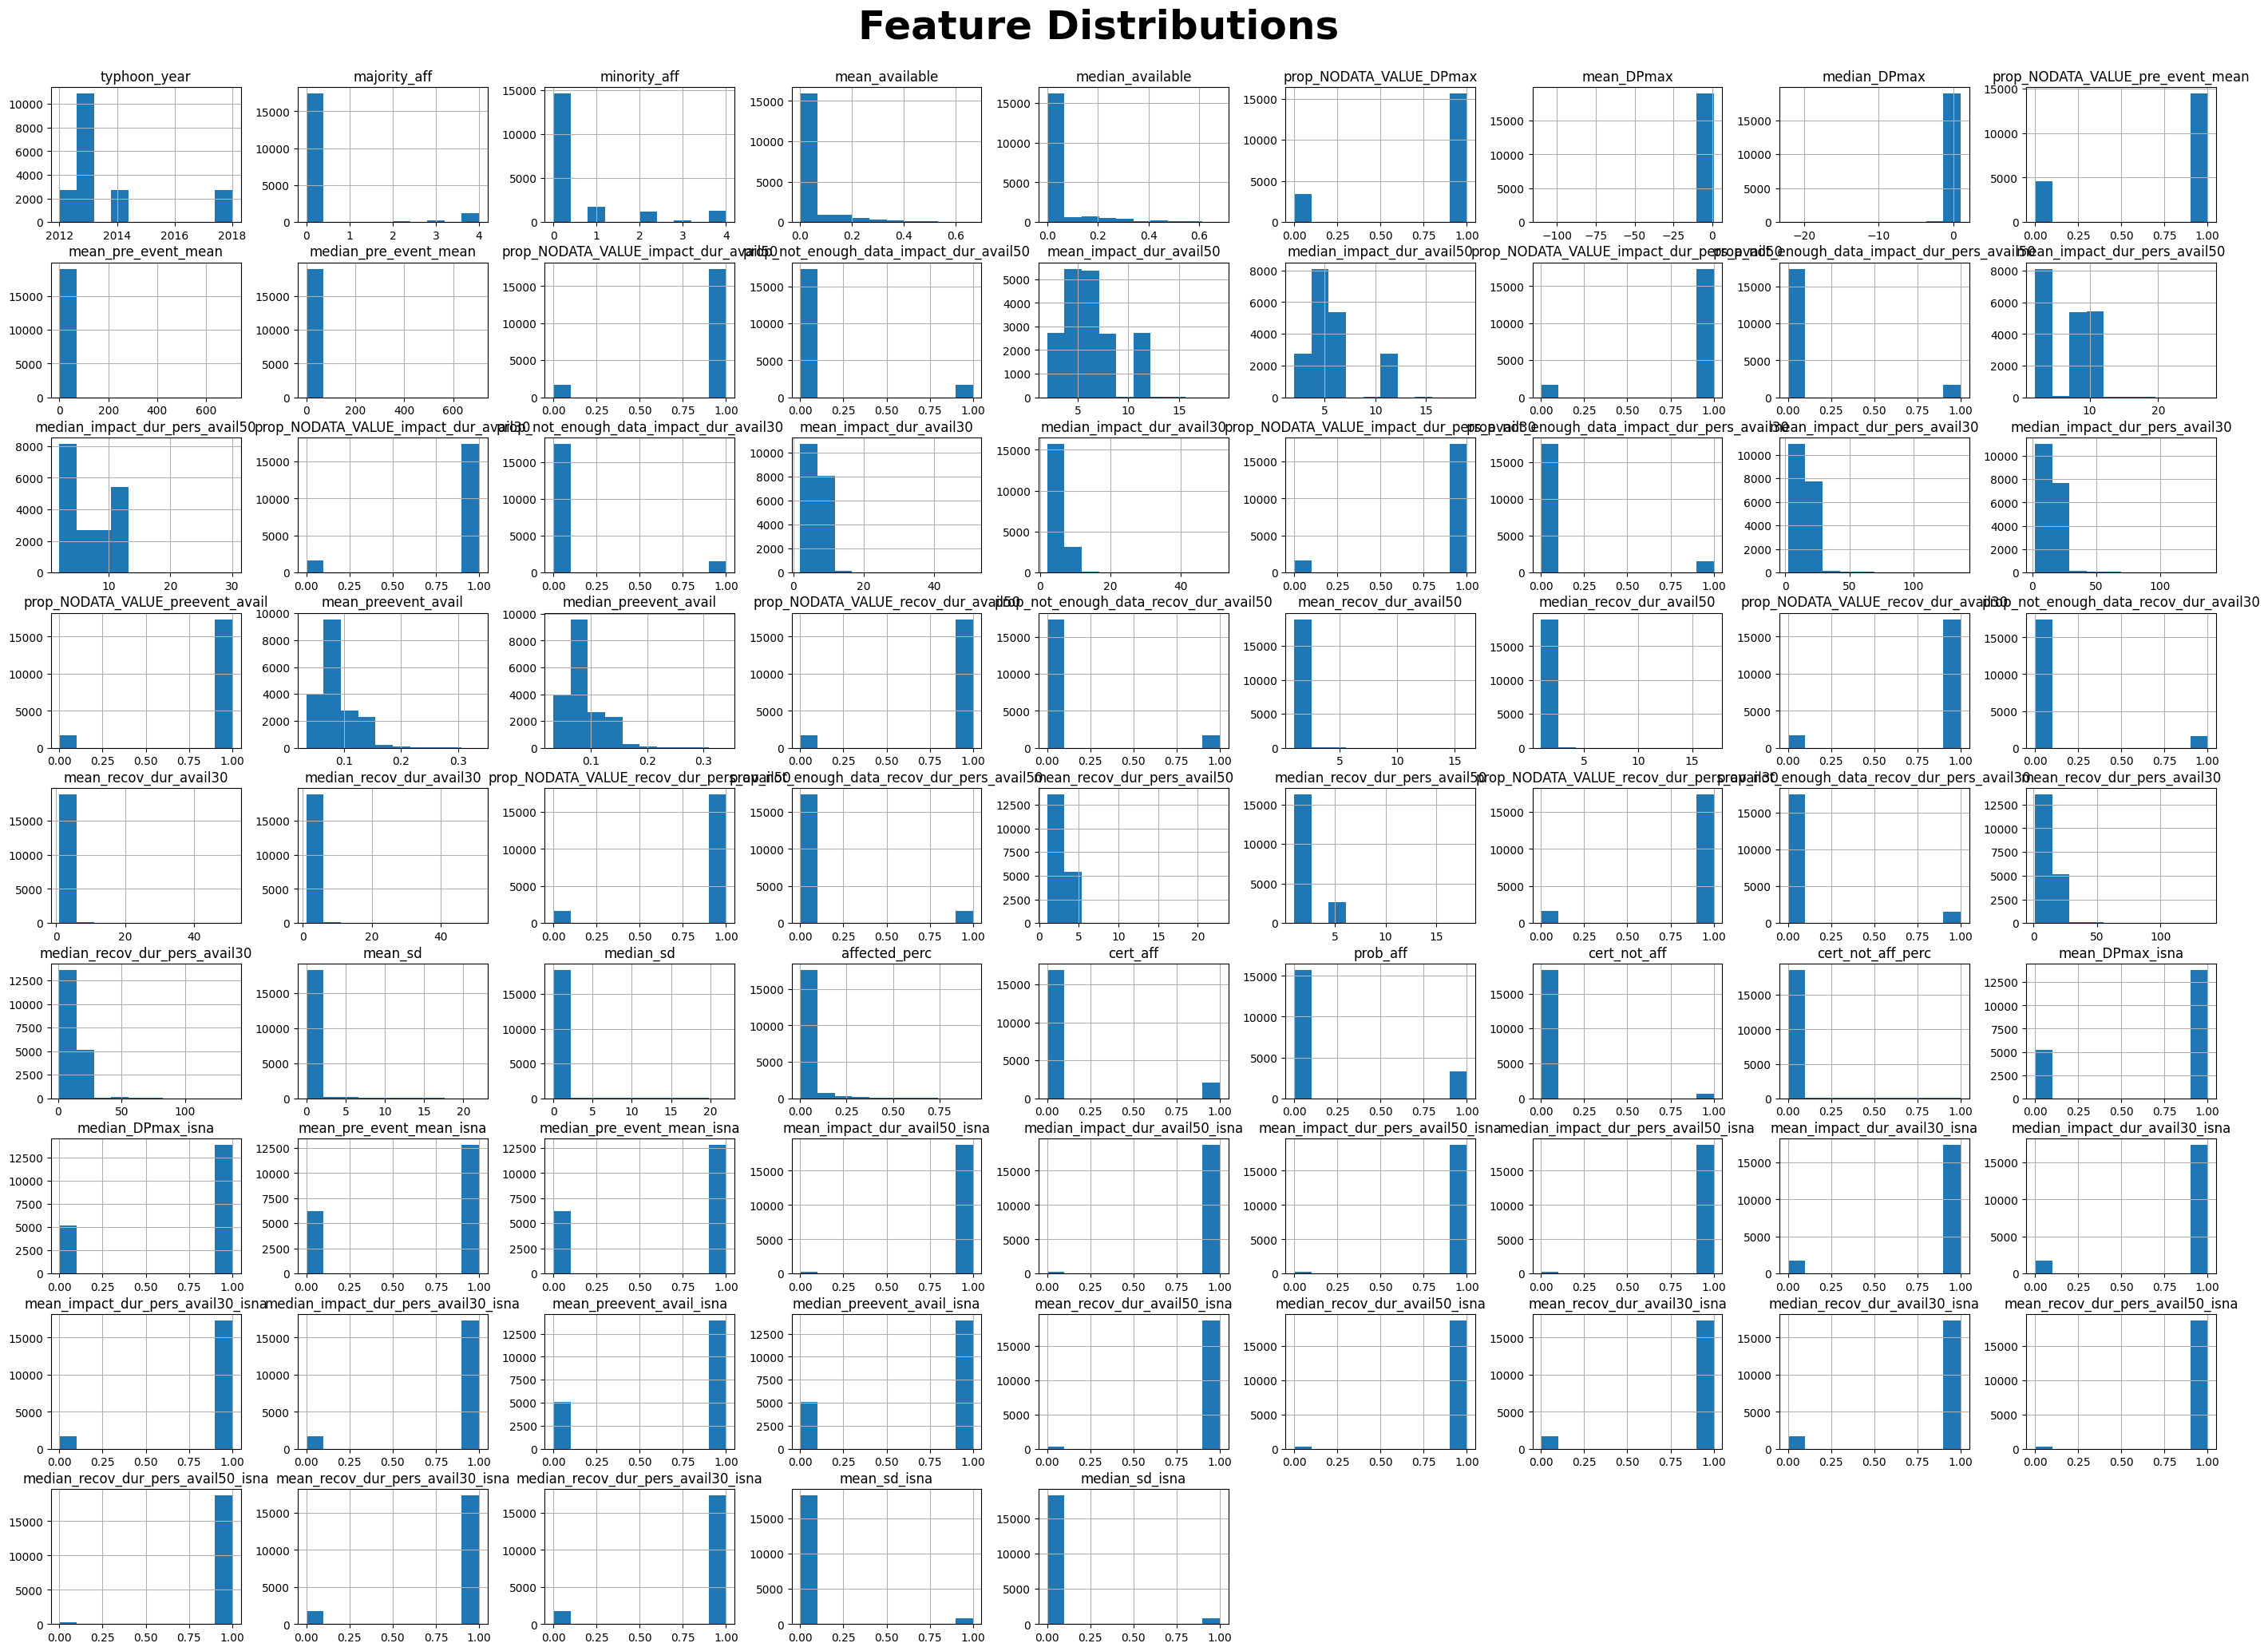

In [37]:
X_train_wo_grid.hist(figsize=(35, 25))
plt.suptitle("Feature Distributions", fontsize=36, fontweight='bold', y=0.92)
plt.show()

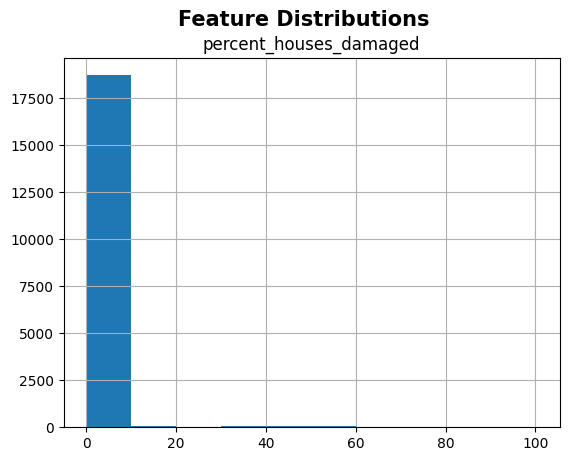

In [59]:
y_train.hist()
plt.suptitle("Feature Distributions", fontsize=15, fontweight='bold', y=0.98)
plt.show()

### Baseline model:

**with grid:**

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import RepeatedKFold

#from before:
# Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

rf_model_w_grid_scaled = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42
)

scaler = MinMaxScaler()
pipeline = Pipeline([('s',scaler),('m',rf_model_w_grid_scaled)])

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate the model
# m_scores = cross_val_score(pipeline, X_train_w_grid, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
# rmse_scores = (-m_scores) ** 0.5
# print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

r2_scores_scale = cross_val_score(pipeline, X_train_w_grid, y_train, scoring='r2', cv=cv, n_jobs=-1)
print(f"R2:   {r2_scores_scale.mean():.4f} ± {r2_scores_scale.std():.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

R2:   0.7129 ± 0.0874


In [48]:
#from before:
# Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

rf_model_w_grid_scaled = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42
)

scaler = StandardScaler()
pipeline = Pipeline([('s',scaler),('m',rf_model_w_grid_scaled)])

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate the model
# m_scores = cross_val_score(pipeline, X_train_w_grid, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
# rmse_scores = (-m_scores) ** 0.5
# print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

r2_scores_scale = cross_val_score(pipeline, X_train_w_grid, y_train, scoring='r2', cv=cv, n_jobs=-1)
print(f"R2:   {r2_scores_scale.mean():.4f} ± {r2_scores_scale.std():.4f}")

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

R2:   0.7105 ± 0.0870


In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, classification_report
import numpy as np

# Create binary target: 1 = any damage, 0 = no damage
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print(f"Damage rate: {y_train_binary.mean().values[0]:.2%}")  # check class balance

# Stage 1 pipeline - classifier
stage1_pipeline = Pipeline([
    ('s', StandardScaler()),
    ('m', RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42,class_weight='balanced'))
])
stage1_pipeline.fit(X_train_wo_grid, y_train_binary)

# Evaluate classifier
y_pred_binary = stage1_pipeline.predict(X_test_wo_grid)
print(classification_report(y_test_binary, y_pred_binary))

from sklearn.metrics import classification_report

y_pred_binary = stage1_pipeline.predict(X_test_wo_grid)
print(classification_report(y_test_binary, y_pred_binary))

# Also check stage 2 in isolation
damaged_mask_test_true = (y_test > 0).values
stage2_r2 = r2_score(
    y_test.values[damaged_mask_test_true],
    stage2_pipeline.predict(X_test_wo_grid[damaged_mask_test_true])
)
print(f"Stage 2 isolated R² (true damaged only): {stage2_r2:.4f}")

Damage rate: 10.93%


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.97      0.75      0.84      5615
           1       0.30      0.83      0.44       724

    accuracy                           0.76      6339
   macro avg       0.63      0.79      0.64      6339
weighted avg       0.89      0.76      0.80      6339



In [79]:
damaged_mask_train = (y_train > 0).values  # .values converts to numpy array

X_train_damaged = X_train_wo_grid[damaged_mask_train]
y_train_damaged = y_train.values[damaged_mask_train]  # .values here too

print(f"NaNs in y_train_damaged: {np.isnan(y_train_damaged).sum()}")  # should be 0
print(f"Training regressor on {damaged_mask_train.sum()} damaged samples")

stage2_pipeline.fit(X_train_damaged, y_train_damaged)

NaNs in y_train_damaged: 0
Training regressor on 2079 damaged samples


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('s', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` a

In [80]:
# Step 1: predict whether damage occurred
damage_predicted = stage1_pipeline.predict(X_test_wo_grid)

# Step 2: for rows predicted as damaged, predict magnitude
y_pred_final = np.zeros(len(X_test_wo_grid))

damaged_mask_test = damage_predicted == 1
if damaged_mask_test.sum() > 0:
    y_pred_final[damaged_mask_test] = stage2_pipeline.predict(
        X_test_wo_grid[damaged_mask_test]
    )

# Evaluate combined result
test_r2 = r2_score(y_test, y_pred_final)
print(f"Two-stage Test R²: {test_r2:.4f}")

Two-stage Test R²: 0.0324


In [84]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

dummy = DummyRegressor(strategy='median')

dummy_r2 = cross_val_score(dummy, X_train_wo_grid, y_train, scoring='r2', cv=5)
print(f"Baseline R²: {dummy_r2.mean():.4f}")

# Also check on test set
dummy.fit(X_train_wo_grid, y_train)
y_pred_dummy = dummy.predict(X_test_wo_grid)
print(f"Baseline Test R²: {r2_score(y_test, y_pred_dummy):.4f}")

Baseline R²: -0.0162
Baseline Test R²: -0.0160


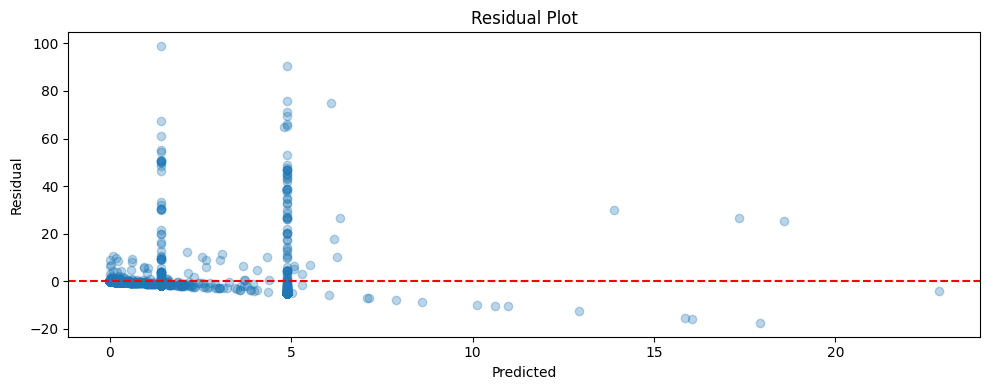

In [88]:
y_pred = pipeline.predict(X_test_wo_grid)
residuals = y_test.values.flatten() - y_pred

plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [87]:
print(f"y_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"X_test shape: {X_test_wo_grid.shape}")

y_test shape: (6339, 1)
y_pred shape: (6339,)
X_test shape: (6339, 77)


THe regualr part of modeling:

In [ ]:
# Initialize the Random Forest model with default hyperparameters
rf_model_w_grid = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
# Cross-validation with R²
r2_scores = cross_val_score(rf_model_w_grid, X_train_w_grid, y_train, cv=5, scoring='r2')
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
# Cross-validation with RMSE
rmse_scores = cross_val_score(rf_model_w_grid, X_train_w_grid, y_train, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
std_rmse = np.std(rmse_scores)
# Train and predict
rf_model_w_grid.fit(X_train_w_grid, y_train)
y_pred_w_grid = rf_model_w_grid.predict(X_test_w_grid)
# Test set metrics
test_r2 = r2_score(y_test, y_pred_w_grid)
test_rmse = root_mean_squared_error(y_test, y_pred_w_grid)
print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"Test Set R²:           {test_r2:.4f}")
print(f"Test Set RMSE:         {test_rmse:.4f}")

# Cross-validation R²:   0.6528 ± 0.0683
# Cross-validation RMSE: 3.2472 ± 0.3005
# Test Set R²:           0.6662
# Test Set RMSE:         3.0420

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   0.6528 ± 0.0683
Cross-validation RMSE: 3.2472 ± 0.3005
Test Set R²:           0.6662
Test Set RMSE:         3.0420


**without grid:**

In [ ]:
# Initialize the Random Forest model with default hyperparameters
rf_model_wo_grid = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
# Cross-validation with R²
r2_scores_wo_grid = cross_val_score(rf_model_wo_grid, X_train_wo_grid, y_train, cv=5, scoring='r2')
mean_r2_wo_grid = np.mean(r2_scores_wo_grid)
std_r2_wo_grid = np.std(r2_scores_wo_grid)
# Cross-validation with RMSE
rmse_scores_wo_grid = cross_val_score(rf_model_wo_grid, X_train_wo_grid, y_train, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse_wo_grid = -np.mean(rmse_scores_wo_grid)  # Negate to get positive value
std_rmse_wo_grid = np.std(rmse_scores_wo_grid)
# Train and predict
rf_model_wo_grid.fit(X_train_wo_grid, y_train)
y_pred_wo_grid = rf_model_wo_grid.predict(X_test_wo_grid)
# Test set metrics
test_r2_wo_grid = r2_score(y_test, y_pred_wo_grid)
test_rmse_wo_grid = root_mean_squared_error(y_test, y_pred_wo_grid)
print(f"Cross-validation R²:   {mean_r2_wo_grid:.4f} ± {std_r2_wo_grid:.4f}")
print(f"Cross-validation RMSE: {mean_rmse_wo_grid:.4f} ± {std_rmse_wo_grid:.4f}")
print(f"Test Set R²:           {test_r2_wo_grid:.4f}")
print(f"Test Set RMSE:         {test_rmse_wo_grid:.4f}")

# Cross-validation R²:   0.0763 ± 0.0683
# Cross-validation RMSE: 5.3713 ± 0.3005
# Test Set R²:           0.0669
# Test Set RMSE:         5.0864

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   0.0763 ± 0.0683
Cross-validation RMSE: 5.3713 ± 0.3005
Test Set R²:           0.0669
Test Set RMSE:         5.0864


#### Model with grid search and CV for hyper parameter tuning:

**with grid:**

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

grid_search_w_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=1  # print progress
)

grid_search_w_grid.fit(X_train_w_grid, y_train)

print(f"Best Parameters: {grid_search_w_grid.best_params_}")
print(f"Best CV R²:      {grid_search_w_grid.best_score_:.4f}")

# Use the best model on the test set
best_model_w_grid = grid_search_w_grid.best_estimator_
y_pred_w_grid = best_model_w_grid.predict(X_test_w_grid)
test_r2_w_grid = r2_score(y_test, y_pred_w_grid)
print(f"Test Set R²:     {test_r2_w_grid:.4f}")

#results:
# Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
# Best CV R²:      0.6613
# Test Set R²:     0.6896

**without grid:**

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 5, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None],
}

grid_search_wo_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=2  # don't print progress
)

grid_search_wo_grid.fit(X_train_wo_grid, y_train)

print(f"Best Parameters: {grid_search_wo_grid.best_params_}")
print(f"Best CV R²:      {grid_search_wo_grid.best_score_:.4f}")

# Use the best model on the test set
best_model_wo_grid = grid_search_wo_grid.best_estimator_
y_pred_wo_grid = best_model_wo_grid.predict(X_test_wo_grid)
test_r2_wo_grid = r2_score(y_test, y_pred_wo_grid)
print(f"Test Set R²:     {test_r2_wo_grid:.4f}")

# results:
# Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# Best CV R²:      0.0783
# Test Set R²:     0.0688

In [ ]:
rf_model_wo_grid_scaled = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
scaler = StandardScaler()
pipeline = Pipeline([('s', scaler), ('m', rf_model_wo_grid_scaled)])

# Cross-val score on training data
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
m_scores = cross_val_score(pipeline, X_train_wo_grid, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
r2_scores = cross_val_score(pipeline, X_train_wo_grid, y_train, scoring='r2', cv=cv, n_jobs=-1)
rmse_scores = (-m_scores) ** 0.5
print(f"CV RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"CV R2:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# Fit on full training data and predict test set
pipeline.fit(X_train_wo_grid, y_train)
y_pred_wo_grid = pipeline.predict(X_test_wo_grid)
test_r2 = r2_score(y_test, y_pred_wo_grid)
print(f"Test Set R²: {test_r2:.4f}")

# CV RMSE: 5.3653 ± 0.7194
# CV R2:   0.0757 ± 0.0225
# Test Set R²: 0.0687

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

CV RMSE: 5.3653 ± 0.7194
CV R2:   0.0757 ± 0.0225


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Test Set R²: 0.0687


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

binary_cols = [c for c in X_train_wo_grid.columns if X_train_wo_grid[c].nunique() == 2]
continuous_cols = [c for c in X_train_wo_grid.columns if c not in binary_cols]

preprocessor = ColumnTransformer([
    ('scale', PowerTransformer(), continuous_cols),
    ('passthrough', 'passthrough', binary_cols)
])

pipeline = Pipeline([('pre', preprocessor), ('m', rf_model_wo_grid_scaled)])

# Cross-val score on training data
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
m_scores = cross_val_score(pipeline, X_train_wo_grid, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
r2_scores = cross_val_score(pipeline, X_train_wo_grid, y_train, scoring='r2', cv=cv, n_jobs=-1)
rmse_scores = (-m_scores) ** 0.5
print(f"CV RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"CV R2:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# Fit on full training data and predict test set
pipeline.fit(X_train_wo_grid, y_train)
y_pred_wo_grid = pipeline.predict(X_test_wo_grid)
test_r2 = r2_score(y_test, y_pred_wo_grid)
print(f"Test Set R²: {test_r2:.4f}")

# CV RMSE: 5.3663 ± 0.7172
# CV R2:   0.0753 ± 0.0220
# Test Set R²: 0.0689

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

CV RMSE: 5.3663 ± 0.7172
CV R2:   0.0753 ± 0.0220


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Test Set R²: 0.0689


The more simplistic method:

In [13]:
#shoudl already have all this run above
# na_cols = get_na_columns(X)
# bad_storms = find_bad_storms(df, na_cols)
# df_clean = df[~df['typhoon_name'].isin(bad_storms)]

# y = df_clean[['percent_houses_damaged']]
# X = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, random_state=42)

na_columns = get_na_columns(X)
# get medians
storm_medians = calculate_storm_medians(X_train_2, na_columns)
global_medians = X_train_2[na_columns].median().to_dict()  # fallback for unseen storms

X_train_imputed = impute_with_storm_medians(X_train_2, storm_medians, na_columns, global_medians)
X_test_imputed  = impute_with_storm_medians(X_test_2, storm_medians, na_columns, global_medians)

# drop columns that only have one value and therefore don't provide value
cols_to_drop = []
for col in X_train_imputed.columns:
    if X_train_imputed[col].value_counts().shape[0] == 1:
        cols_to_drop.append(col)
    
X_train_imputed.drop(columns=cols_to_drop, inplace=True)
X_test_imputed.drop(columns=cols_to_drop, inplace=True)

train_grid_id_2 = X_train_imputed['grid_point_id']
test_grid_id_2 = X_test_imputed['grid_point_id']

# with grid
X_train_imputed_w_grid = X_train_imputed.drop(columns=['typhoon_name'])
X_test_imputed_w_grid = X_test_imputed.drop(columns=['typhoon_name'])

# without grid
X_train_imputed_wo_grid = X_train_imputed.drop(columns=['typhoon_name','grid_point_id'])
X_test_imputed_wo_grid = X_test_imputed.drop(columns=['typhoon_name','grid_point_id'])

#### Baseline model:

**with grid**

In [ ]:
# Initialize the Random Forest model with default hyperparameters
rf_model_w_grid_simp = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
# Cross-validation with R²
r2_scores_w_simp = cross_val_score(rf_model_w_grid_simp, X_train_imputed_w_grid, y_train_2, cv=5, scoring='r2')
mean_r2_w_simp = np.mean(r2_scores_w_simp)
std_r2_w_simp = np.std(r2_scores_w_simp)
# Cross-validation with RMSE
rmse_scores_w_simp = cross_val_score(rf_model_w_grid_simp, X_train_imputed_w_grid, y_train_2, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse_w_simp = -np.mean(rmse_scores_w_simp)  # Negate to get positive value
std_rmse_w_simp = np.std(rmse_scores_w_simp)
# Train and predict
rf_model_w_grid_simp.fit(X_train_imputed_w_grid, y_train_2)
y_pred_w_simp = rf_model_w_grid_simp.predict(X_test_imputed_w_grid)
# Test set metrics
test_r2_w_simp = r2_score(y_test_2, y_pred_w_simp)
test_rmse_w_simp = root_mean_squared_error(y_test_2, y_pred_w_simp)
print(f"Cross-validation R²:   {mean_r2_w_simp:.4f} ± {std_r2_w_simp:.4f}")
print(f"Cross-validation RMSE: {mean_rmse_w_simp:.4f} ± {std_rmse_w_simp:.4f}")
print(f"Test Set R²:           {test_r2_w_simp:.4f}")
print(f"Test Set RMSE:         {test_rmse_w_simp:.4f}")

# Cross-validation R²:   -0.1302 ± 0.1948
# Cross-validation RMSE: 5.8690 ± 0.4212
# Test Set R²:           -0.0088
# Test Set RMSE:         5.2885

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   -0.1302 ± 0.1948
Cross-validation RMSE: 5.8690 ± 0.4212
Test Set R²:           -0.0088
Test Set RMSE:         5.2885


**without grid**:

In [ ]:
# Initialize the Random Forest model with default hyperparameters
rf_model_wo_grid_simp = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
# Cross-validation with R²
r2_scores_wo_simp = cross_val_score(rf_model_wo_grid_simp, X_train_imputed_wo_grid, y_train_2, cv=5, scoring='r2')
mean_r2_wo_simp = np.mean(r2_scores_wo_simp)
std_r2_wo_simp = np.std(r2_scores_wo_simp)
# Cross-validation with RMSE
rmse_scores_wo_simp = cross_val_score(rf_model_wo_grid_simp, X_train_imputed_wo_grid, y_train_2, cv=5, scoring='neg_root_mean_squared_error')
mean_rmse_wo_simp = -np.mean(rmse_scores_wo_simp)  # Negate to get positive value
std_rmse_wo_simp = np.std(rmse_scores_wo_simp)
# Train and predict
rf_model_wo_grid_simp.fit(X_train_imputed_wo_grid, y_train_2)
y_pred_wo_simp = rf_model_wo_grid_simp.predict(X_test_imputed_wo_grid)
# Test set metrics
test_r2_wo_simp = r2_score(y_test_2, y_pred_wo_simp)
test_rmse_wo_simp = root_mean_squared_error(y_test_2, y_pred_wo_simp)
print(f"Cross-validation R²:   {mean_r2_wo_simp:.4f} ± {std_r2_wo_simp:.4f}")
print(f"Cross-validation RMSE: {mean_rmse_wo_simp:.4f} ± {std_rmse_wo_simp:.4f}")
print(f"Test Set R²:           {test_r2_wo_simp:.4f}")
print(f"Test Set RMSE:         {test_rmse_wo_simp:.4f}")

# Cross-validation R²:   0.0063 ± 0.0096
# Cross-validation RMSE: 5.5710 ± 0.6724
# Test Set R²:           0.0202
# Test Set RMSE:         5.2122

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Cross-validation R²:   0.0063 ± 0.0096
Cross-validation RMSE: 5.5710 ± 0.6724
Test Set R²:           0.0202
Test Set RMSE:         5.2122


Model with grid search and CV for hyper parameter tuning:

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

grid_search_w_grid_2 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=1  # print progress
)

grid_search_w_grid_2.fit(X_train_imputed_w_grid, y_train_2)

print(f"Best Parameters: {grid_search_w_grid_2.best_params_}")
print(f"Best CV R²:      {grid_search_w_grid_2.best_score_:.4f}")

# Use the best model on the test set
best_model_w_grid_2 = grid_search_w_grid_2.best_estimator_
y_pred_w_grid_2 = best_model_w_grid_2.predict(X_test_imputed_w_grid)
test_r2_w_grid_2 = r2_score(y_test_2, y_pred_w_grid_2)
print(f"Test Set R²:     {test_r2_w_grid_2:.4f}")

#results:
# Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# Best CV R²:      0.1206
# Test Set R²:     0.2248

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²:      0.1206
Test Set R²:     0.2248


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

grid_search_wo_grid_2 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=1  # print progress
)

grid_search_wo_grid_2.fit(X_train_imputed_wo_grid, y_train_2)

print(f"Best Parameters: {grid_search_wo_grid_2.best_params_}")
print(f"Best CV R²:      {grid_search_wo_grid_2.best_score_:.4f}")

# Use the best model on the test set
best_model_w_grid_2 = grid_search_wo_grid_2.best_estimator_
y_pred_wo_grid_2 = best_model_w_grid_2.predict(X_test_imputed_wo_grid)
test_r2_wo_grid_2 = r2_score(y_test_2, y_pred_wo_grid_2)
print(f"Test Set R²:     {test_r2_wo_grid_2:.4f}")

# Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
# Best CV R²:      0.0134
# Test Set R²:     0.0216

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²:      0.0134
Test Set R²:     0.0216


One more treebased model that had preformed better earlier:

In [58]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2', None],
}

grid_search_wo_grid_et = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=1  # print progress
)

grid_search_wo_grid_et.fit(X_train_imputed_wo_grid, y_train_2)

print(f"Best Parameters: {grid_search_wo_grid_et.best_params_}")
print(f"Best CV R²:      {grid_search_wo_grid_et.best_score_:.4f}")

# Use the best model on the test set
best_model_w_grid_et = grid_search_wo_grid_et.best_estimator_
y_pred_wo_grid_et = best_model_w_grid_et.predict(X_test_imputed_wo_grid)
test_r2_wo_grid_et = r2_score(y_test_2, y_pred_wo_grid_et)
print(f"Test Set R²:     {test_r2_wo_grid_et:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²:      0.0153
Test Set R²:     0.0176


Forgot to do this before, dropping highly correlated features to see if it improved results here:

In [89]:
corr_cols_to_drop = drop_correlated_features(X_train_wo_grid,y_train,method='spearman')

X_train_wo_grid_dropped = X_train_wo_grid.drop(columns=corr_cols_to_drop)
X_test_wo_grid_dropped = X_test_wo_grid.drop(columns=corr_cols_to_drop)

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 5, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None],
}

grid_search_wo_grid_d = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=1
)

grid_search_wo_grid_d.fit(X_train_wo_grid_dropped, y_train)

print(f"Best Parameters: {grid_search_wo_grid_d.best_params_}")
print(f"Best CV R²:      {grid_search_wo_grid_d.best_score_:.4f}")

# Use the best model on the test set
best_model_wo_grid_d = grid_search_wo_grid_d.best_estimator_
y_pred_wo_grid_d = best_model_wo_grid_d.predict(X_test_wo_grid_dropped)
test_r2_wo_grid_d = r2_score(y_test, y_pred_wo_grid_d)
print(f"Test Set R²:     {test_r2_wo_grid_d:.4f}")

# old results:
# Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# Best CV R²:       
# Test Set R²:     0.0688

#new results:
# Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
# Best CV R²:      0.0736
# Test Set R²:     0.0731

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²:      0.0736
Test Set R²:     0.0731


In [94]:
corr_cols_to_drop_2 = drop_correlated_features(X_train_imputed_wo_grid,y_train_2,method='spearman')

X_train_imp_wo_grid_dropped = X_train_imputed_wo_grid.drop(columns=corr_cols_to_drop_2)
X_test_imp_wo_grid_dropped = X_test_wo_grid.drop(columns=corr_cols_to_drop_2)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
}

grid_search_wo_grid_2_2 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42,max_features = 'sqrt'),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1, # use all CPU cores
    verbose=1  # print progres
)

grid_search_wo_grid_2_2.fit(X_train_imp_wo_grid_dropped, y_train_2)

print(f"Best Parameters: {grid_search_wo_grid_2_2.best_params_}")
print(f"Best CV R²:      {grid_search_wo_grid_2_2.best_score_:.4f}")

# Use the best model on the test set
best_model_w_grid_2_2 = grid_search_wo_grid_2_2.best_estimator_
y_pred_wo_grid_2_2 = best_model_w_grid_2_2.predict(X_test_imp_wo_grid_dropped)
test_r2_wo_grid_2_2 = r2_score(y_test_2, y_pred_wo_grid_2_2)
print(f"Test Set R²:     {test_r2_wo_grid_2_2:.4f}")

# Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
# Best CV R²:      0.0134
# Test Set R²:     0.0216

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/ele

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R²:      0.0142
Test Set R²:     -0.0076


Model Comparisons:

So, far the more complicated imputation is the better method for prediction. So, this is the one we will use. However, so far the models aren't quite preforming as well as we'd hope. Will do some more preprocessing to see if there's anything we can do to help our model fit better.